Column names: ['Timestamp', 'Electricity_Consumed', 'Temperature', 'Humidity', 'Wind_Speed', 'Avg_Past_Consumption', 'Anomaly_Label']
Dataset Shape: (5000, 7)


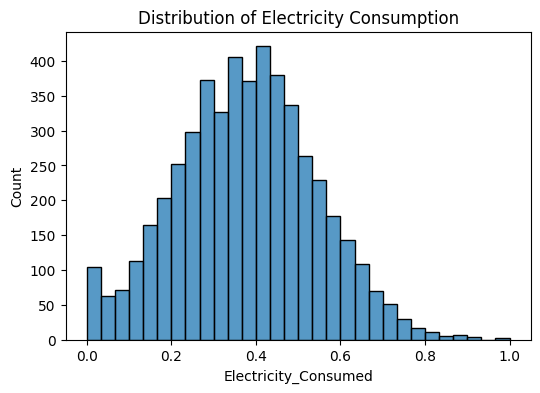

Target column detected manually: 'Electricity_Consumed'

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Electricity_Consumed  5000 non-null   float64
 1   Temperature           5000 non-null   float64
 2   Humidity              5000 non-null   float64
 3   Wind_Speed            5000 non-null   float64
 4   Avg_Past_Consumption  5000 non-null   float64
 5   Hour                  5000 non-null   int32  
 6   DayOfWeek             5000 non-null   int32  
dtypes: float64(5), int32(2)
memory usage: 234.5 KB
None
MSE: 0.02447572192256107
MAE: 0.12578429603947194
R² Score: 0.05086093950746573


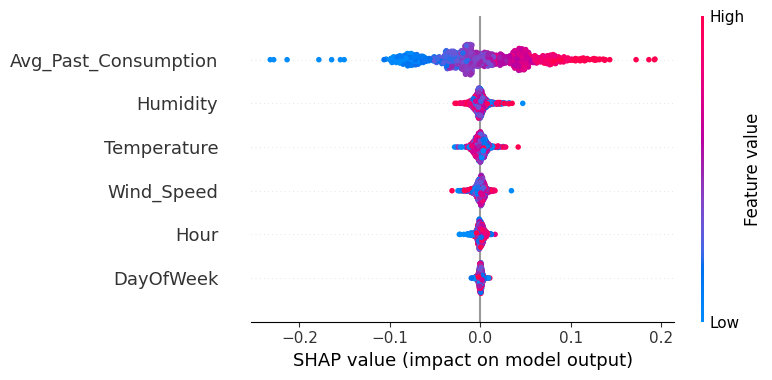

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


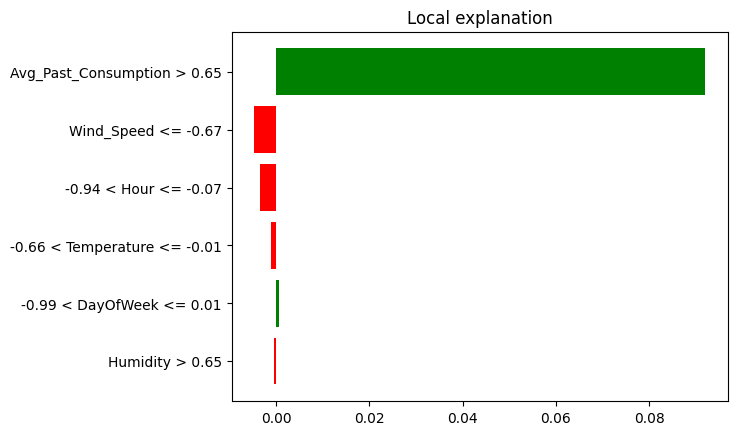

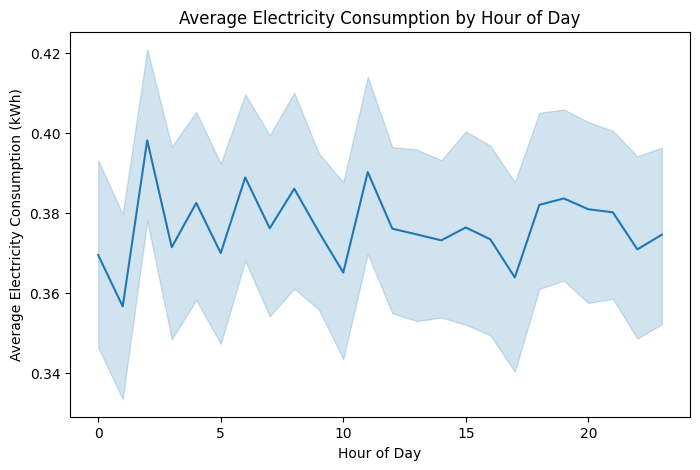

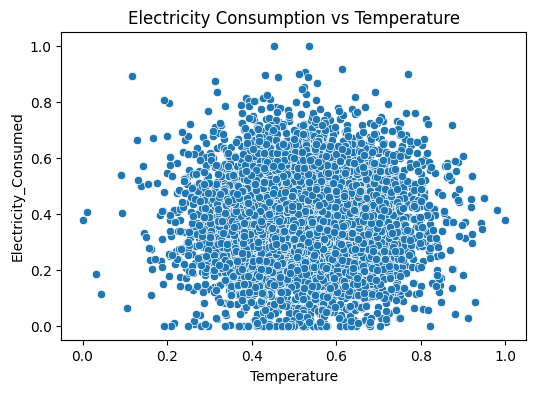

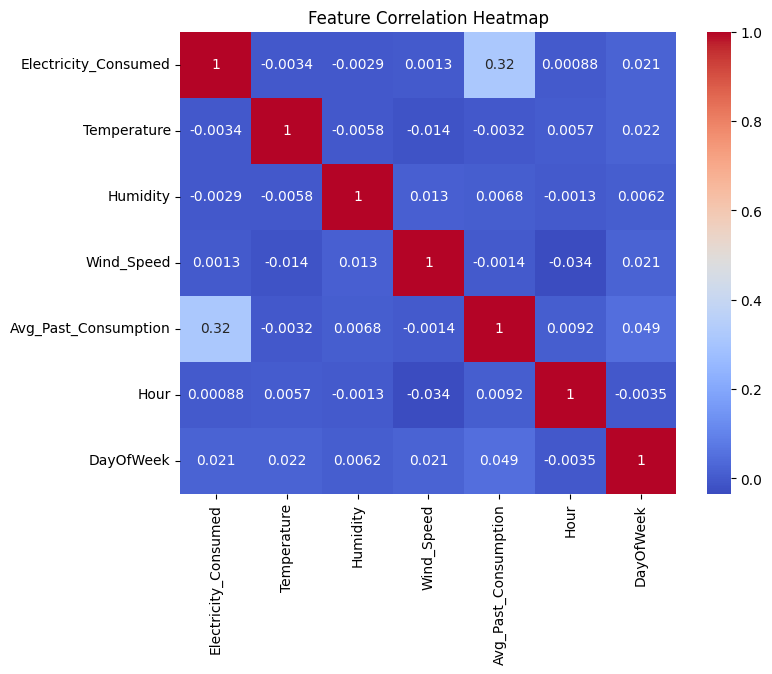

                Feature  Importance
3  Avg_Past_Consumption    0.419442
1              Humidity    0.162102
0           Temperature    0.151571
2            Wind_Speed    0.138978
4                  Hour    0.080757
5             DayOfWeek    0.047150


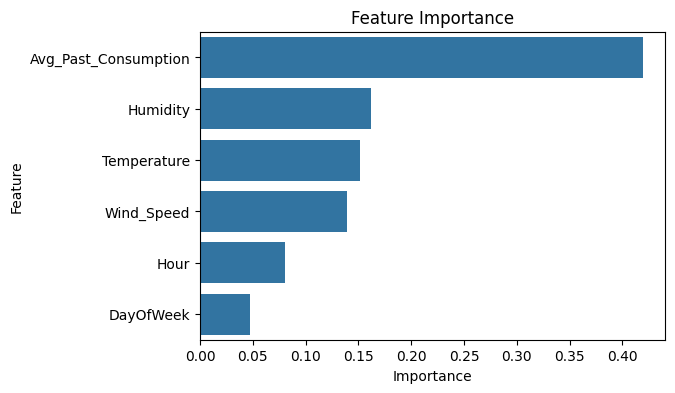


--- Displaying Sample Predictions (y_pred) and Test Features (X_test) ---

10 Predicted Electricity Consumption (X_test):
      Temperature  Humidity  Wind_Speed  Avg_Past_Consumption      Hour  \
1501    -1.188007  0.410303    0.913358              2.672991 -0.791533   
2586    -1.018816  1.411168   -0.825999              1.313143  1.373491   
2653     0.487624  0.372059   -1.350475             -0.221890 -0.791533   
1055     1.494699 -0.756538   -0.547444              0.371097  1.662161   
705     -2.054681 -0.717983    1.370093             -0.922046  0.651817   
106     -1.009662  0.553093   -0.228753             -0.300552 -0.935868   
589      1.534339 -0.381082   -1.484855              0.595270 -0.791533   
2468    -0.407273  1.517682   -1.467056              0.702364 -0.214193   
2413     0.405681  0.594154   -1.055682              0.791938 -0.791533   
1600    -1.266516 -1.868972    0.455352             -0.810880 -0.502863   

      DayOfWeek  
1501   0.012061  
2586   0.514617

In [2]:
# SmartGridXAI: Explainable AI for Electricity Demand Prediction
## Objective: Predict electricity consumption using smart meter data and explain the factors influencing energy demand
## Techniques Used: Random Forest Regressor, SHAP (Global Explainability), LIME (Local Explainability)
## Applications: Smart grid energy forecasting, Energy demand planning, Utility load management


# Step 1: Install libraries
!pip install scikit-learn matplotlib seaborn shap lime --quiet

# Step 2: Import required libraries
# Loads modules for data, ML, and visualization.

import pandas as pd  # Data manipulation (DataFrames)
import numpy as np   # Numerical operations (arrays)
import matplotlib.pyplot as plt # Basic plotting
import seaborn as sns # Enhanced statistical plots
import shap         # SHAP for model explanations
from lime import lime_tabular # LIME for tabular data
import os           # Operating system interactions
from sklearn.model_selection import train_test_split # Splits data into train/test
from sklearn.preprocessing import LabelEncoder, StandardScaler # Preprocessing: categorical to numeric, standardize features
from sklearn.ensemble import RandomForestRegressor # Ensemble regression model
from sklearn.metrics import mean_squared_error, mean_absolute_error # Model evaluation metrics
from IPython.display import Image, display

# Step 3: Load Smart Meter Electricity Consumption Dataset
# The dataset contains weather variables, historical consumption, and timestamps
df = pd.read_csv('/Xpecto/smart_meter_data.csv')

# Show all column names to diagnose hidden characters
print("Column names:", df.columns.tolist())
print("Dataset Shape:", df.shape) #(number_of_rows, number_of_columns)
# Clean column names (strip any extra spaces)
df.columns = df.columns.str.strip()
df.head()
df.describe() # Data Exploration
# Data Visualization
plt.figure(figsize=(6,4))
sns.histplot(df["Electricity_Consumed"], bins=30)
plt.title("Distribution of Electricity Consumption")
plt.show()

# Step 4: Feature engineering
# Convert timestamp into datetime format and extract useful temporal features
# These features help capture consumption patterns during different hours and days.
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    df = df.drop(columns=['Timestamp'])

# Step 5: Data Cleaning (remove irrelevant columns if needed)
## Drop any unwanted columns if necessary

if 'Anomaly_Label' in df.columns:
    df = df.drop(columns=['Anomaly_Label'])

# Manually set target column (e.g., electricity consumption or similar)
target_col = 'Electricity_Consumed'  # Define prediction target: electricity consumption (kWh)
# The model will learn to predict energy demand based on environmental and historical features
print(f"Target column detected manually: '{target_col}'")

print("\nDataset Info:")
print(df.info())

# Encode categorical variables into numeric format so the ML model can process them
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))


# Step 6: Preprocessing
X = df.drop(target_col, axis=1)
y = df[target_col]
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
# Step 7: Train model
# Train a Random Forest regression model to predict electricity consumption
# Random Forest is chosen because it captures nonlinear relationships and works well with tabular data
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)


# Step 8: Evaluate model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = model.score(X_test, y_test)
print("MSE:", mse)
print("MAE:", mae)
print("R² Score:", r2)

# Step 9: Global Explainability using SHAP
# This shows which features influence electricity consumption predictions the most
X_test_df = pd.DataFrame(X_test, columns=X.columns)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test_df)

# Step 10: Local Explainability using LIME
# Explains why the model predicted a specific electricity consumption value for a single instance

X_train_np = X_train.values
X_test_np = X_test.values

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    mode="regression"
)

exp = lime_explainer.explain_instance(
    X_test.values[7],
    model.predict
)

fig = exp.as_pyplot_figure()
fig.savefig("lime_explanation.png")
plt.show()
display(exp)

# Step 11: Electricity Consumption using Seaborn

plt.figure(figsize=(8,5))

sns.lineplot(
    x="Hour",
    y="Electricity_Consumed",
    data=df,
    estimator="mean"
)

plt.title("Average Electricity Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Electricity Consumption (kWh)")

plt.show()

### Insight: Electricity Demand Patterns

# Electricity consumption varies across different hours of the day.
# Demand typically increases during evening hours when residential
# activities are highest, such as lighting, cooking, and appliance use.
# Understanding these patterns can help utility companies optimize
# electricity generation and grid management.

plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Temperature",
    y="Electricity_Consumed",
    data=df
)

plt.title("Electricity Consumption vs Temperature")

plt.show()

### Insight: Weather Impact
# Electricity demand tends to increase with temperature due to
# cooling requirements such as air conditioning.
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()
### Insight: Feature Relationships
# Average past consumption shows the strongest correlation
# with electricity demand, confirming that historical usage
# patterns are the most reliable predictor of future energy consumption.
# Step 12: Extract feature importance from Random Forest
# This helps identify which variables most strongly influence energy demand
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(6,4))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()


# Step 13: Display sample predictions along with corresponding input features
# This helps verify the model’s prediction behavior

print("\n--- Displaying Sample Predictions (y_pred) and Test Features (X_test) ---")

# Option 1: Display the first N predictions and corresponding X_test rows
num_samples_to_display = 10 # You can change this number


print(f"\n{num_samples_to_display} Predicted Electricity Consumption (X_test):")
print(X_test[:num_samples_to_display])
print(f"\n{num_samples_to_display} Predicted Electricity Consumption (y_pred):")
print(y_pred[:num_samples_to_display])

print(f"\nCorresponding {num_samples_to_display} Test Features (X_test) Scaled:")
# X_test is a NumPy array, but X.columns gives original feature names
# We can wrap it in a DataFrame for better readability with column names
X_test_display = pd.DataFrame(X_test, columns=X.columns)
print(X_test_display.head(num_samples_to_display))

# Option 2: Display a specific instance's prediction and features (e.g., instance at index 14, which you used for LIME)
specific_instance_index = 7

print(f"\nPrediction for Instance {specific_instance_index}:")
print(f"Predicted Electricity Consumption: {y_pred[specific_instance_index]:.2f} kWh")

print(f"\nFeatures for Instance {specific_instance_index} (X_test) Scaled:")
print(X_test_display.iloc[specific_instance_index])

# Option 3: You might also want to see the actual y_test values for comparison
print(f"\nCorresponding True Electricity Consumption (y_test) for Instance {specific_instance_index}:")
print(f"True Electricity Consumption: {y_test.iloc[specific_instance_index]:.2f} kWh")
print(f"Predicted Electricity Consumption: {y_pred[specific_instance_index]:.2f} kWh")

print("\n--- End of Sample Display ---")


## Key Insights

# 1. Average Past Consumption is the strongest predictor of electricity demand.
# 2. Weather factors such as temperature and humidity influence electricity usage.
# 3. Time-based patterns (hour and day of week) affect consumption behaviour.

# These insights highlight predictable patterns in energy demand, which can help utilities plan electricity generation and distribution more efficiently.

## Conclusion

# The SmartGridXAI system demonstrates how machine learning combined with explainable AI can improve electricity demand forecasting.
# The model predicts electricity consumption using historical and environmental factors while providing interpretable explanations through SHAP and LIME.
# Such systems can support smart grid management, energy planning, and sustainability initiatives.

